# Parkinson's Disease Detection Using Biomedical Voice Features

**Team Members**
- Charmilkumar Vijaykumar Patel | SID: 20036845 | cpatel6@stevens.edu
- Yunyang Zhang | SID: 20043349 | yzhang102@stevens.edu

**Dataset:** [Parkinson's Data Set – UCI Machine Learning Repository](https://archive.ics.uci.edu/dataset/174/parkinsons)

In [1]:
import sys
from pathlib import Path
project_root = Path().resolve()
src_dir = project_root / "src"
if str(src_dir) not in sys.path:
    sys.path.insert(0, str(src_dir))

In [2]:
from data_loader import VoiceDataset
from model import ParkinsonPredictor
from utils import summarize_dataset, validate_status_value, summarize_vars
from visualization import VisualizationManager


In [3]:
DATA_PATH = project_root / "data/parkinsons.csv"
OUTPUT_DIR = project_root / "outputs"
dataset = VoiceDataset(DATA_PATH)
data = dataset.load()
data

,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,MDVP:Shimmer(dB),...,Shimmer:DDA,NHR,HNR,status,RPDE,DFA,spread1,spread2,D2,PPE
0,119.992,157.302,74.997,0.00784,0.00007,0.00370,0.00554,0.01109,0.04374,0.426,...,0.06545,0.02211,21.033,1,0.414783,0.815285,-4.813031,0.266482,2.301442,0.284654
1,122.400,148.650,113.819,0.00968,0.00008,0.00465,0.00696,0.01394,0.06134,0.626,...,0.09403,0.01929,19.085,1,0.458359,0.819521,-4.075192,0.335590,2.486855,0.368674
2,116.682,131.111,111.555,0.01050,0.00009,0.00544,0.00781,0.01633,0.05233,0.482,...,0.08270,0.01309,20.651,1,0.429895,0.825288,-4.443179,0.311173,2.342259,0.332634
3,116.676,137.871,111.366,0.00997,0.00009,0.00502,0.00698,0.01505,0.05492,0.517,...,0.08771,0.01353,20.644,1,0.434969,0.819235,-4.117501,0.334147,2.405554,0.368975
4,116.014,141.781,110.655,0.01284,0.00011,0.00655,0.00908,0.01966,0.06425,0.584,...,0.10470,0.01767,19.649,1,0.417356,0.823484,-3.747787,0.234513,2.332180,0.410335
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
190,174.188,230.978,94.261,0.00459,0.00003,0.00263,0.00259,0.00790,0.04087,0.405,...,0.07008,0.02764,19.517,0,0.448439,0.657899,-6.538586,0.121952,2.657476,0.133050
191,209.516,253.017,89.488,0.00564,0.00003,0.00331,0.00292,0.00994,0.02751,0.263,...,0.04812,0.01810,19.147,0,0.431674,0.683244,-6.195325,0.129303,2.784312,0.168895
192,174.688,240.005,74.287,0.01360,0.00008,0.00624,0.00564,0.01873,0.02308,0.256,...,0.03804,0.10715,17.883,0,0.407567,0.655683,-6.787197,0.158453,2.679772,0.131728
193,198.764,396.961,74.904,0.00740,0.00004,0.00370,0.00390,0.01109,0.02296,0.241,...,0.03794,0.07223,19.020,0,0.451221,0.643956,-6.744577,0.207454,2.138608,0.123306


In [4]:
print(dataset)
print(f'{len(dataset)} Samples')

VoiceDataset: 195 rows, 22 features
195 Samples


In [5]:
summary = summarize_dataset(dataset, OUTPUT_DIR)
for s in summary:
    print(s)

Parkinson's Voice Dataset Summary
Rows: 195
Missing Values: 0
Features used: 22
Status counts: {1: 147, 0: 48}
Parkinson's samples: 75.38%
Frequency features: ['MDVP:Fo(Hz)', 'MDVP:Fhi(Hz)', 'MDVP:Flo(Hz)']


In [6]:
# Separating data between healthy individuals and individuals with parkinsons
parkinsondf = data[data['status']==1.0].copy().drop("status", axis=1)
# display(parkinsondf)

nonparkinsondf = data[data['status']==0.0].copy().drop("status", axis=1)
# display(nonparkinsondf)

In [7]:
summarize_vars(parkinsondf, parkinsondf.columns.tolist(), OUTPUT_DIR, "Parkinsons_Positive_Statistical_Summary")

,Variable,Count,Mean,Std (sample),Variance (sample),CV (%),Min,Q1,Median,Q3,Max,IQR,Range,Skewness
0,MDVP:Fo(Hz),147,145.180762,32.348050,1.046396e+03,22.281223,88.333000,117.572000,145.174000,170.071000,223.361000,52.499000,135.028000,0.366850
1,MDVP:Fhi(Hz),147,188.441463,88.339180,7.803811e+03,46.878844,102.145000,133.776500,163.335000,207.160500,588.518000,73.384000,486.373000,2.803273
2,MDVP:Flo(Hz),147,106.893558,32.274358,1.041634e+03,30.192987,65.476000,80.875500,99.770000,129.240000,199.020000,48.364500,133.544000,0.893664
3,MDVP:Jitter(%),147,0.006989,0.005240,2.745537e-05,74.969212,0.001680,0.004005,0.005440,0.007670,0.033160,0.003665,0.031480,2.857486
4,MDVP:Jitter(Abs),147,0.000051,0.000037,1.354329e-09,72.614455,0.000010,0.000030,0.000040,0.000060,0.000260,0.000030,0.000250,2.554055
5,MDVP:RAP,147,0.003757,0.003241,1.050518e-05,86.259063,0.000680,0.002030,0.002840,0.004100,0.021440,0.002070,0.020760,3.059989
6,MDVP:PPQ,147,0.003900,0.002998,8.985075e-06,76.852564,0.000920,0.002190,0.003140,0.004360,0.019580,0.002170,0.018660,2.791292
7,Jitter:DDP,147,0.011273,0.009724,9.454660e-05,86.254365,0.002040,0.006085,0.008530,0.012300,0.064330,0.006215,0.062290,3.061427
8,MDVP:Shimmer,147,0.033658,0.019970,3.988041e-04,59.332052,0.010220,0.018295,0.028380,0.042525,0.119080,0.024230,0.108860,1.370146
9,MDVP:Shimmer(dB),147,0.321204,0.207798,4.318016e-02,64.693565,0.090000,0.168000,0.263000,0.394500,1.302000,0.226500,1.212000,1.716727


In [8]:
summarize_vars(nonparkinsondf, nonparkinsondf.columns.tolist(), OUTPUT_DIR, "Parkinsons_Negative_Statistical_Summary")

,Variable,Count,Mean,Std (sample),Variance (sample),CV (%),Min,Q1,Median,Q3,Max,IQR,Range,Skewness
0,MDVP:Fo(Hz),48,181.937771,52.731067,2.780565e+03,28.983024,110.739000,120.947500,198.996000,229.077000,260.105000,108.129500,149.366000,-0.206080
1,MDVP:Fhi(Hz),48,223.636750,96.727067,9.356126e+03,43.251866,113.597000,139.413250,231.161500,251.239250,592.030000,111.826000,478.433000,2.191357
2,MDVP:Flo(Hz),48,145.207292,58.757070,3.452393e+03,40.464270,74.287000,98.243750,113.938500,199.183000,239.170000,100.939250,164.883000,0.454401
3,MDVP:Jitter(%),48,0.003866,0.002055,4.221475e-06,53.145391,0.001780,0.002655,0.003355,0.004530,0.013600,0.001875,0.011820,2.595196
4,MDVP:Jitter(Abs),48,0.000023,0.000015,2.239840e-10,64.026081,0.000007,0.000010,0.000025,0.000030,0.000080,0.000020,0.000073,1.203508
5,MDVP:RAP,48,0.001925,0.001066,1.136740e-06,55.385989,0.000920,0.001332,0.001625,0.001908,0.006240,0.000575,0.005320,2.227438
6,MDVP:PPQ,48,0.002056,0.000943,8.897478e-07,45.877691,0.001060,0.001480,0.001775,0.002228,0.005640,0.000748,0.004580,1.898408
7,Jitter:DDP,48,0.005776,0.003199,1.023594e-05,55.390277,0.002760,0.003998,0.004875,0.005725,0.018730,0.001727,0.015970,2.227230
8,MDVP:Shimmer,48,0.017615,0.005544,3.074073e-05,31.475257,0.009540,0.014475,0.016705,0.020210,0.040870,0.005735,0.031330,1.632775
9,MDVP:Shimmer(dB),48,0.162958,0.057822,3.343402e-03,35.482790,0.085000,0.129000,0.154000,0.189250,0.405000,0.060250,0.320000,1.744643


In [9]:
summarize_vars(data, data.columns.drop('status').tolist(),OUTPUT_DIR, "Dataset_Statistical_Summary")

,Variable,Count,Mean,Std (sample),Variance (sample),CV (%),Min,Q1,Median,Q3,Max,IQR,Range,Skewness
0,MDVP:Fo(Hz),195,154.228641,41.390065,1.713137e+03,26.836821,88.333000,117.572000,148.790000,182.769000,260.105000,65.197000,171.772000,0.591737
1,MDVP:Fhi(Hz),195,197.104918,91.491548,8.370703e+03,46.417689,102.145000,134.862500,175.829000,224.205500,592.030000,89.343000,489.885000,2.542146
2,MDVP:Flo(Hz),195,116.324631,43.521413,1.894113e+03,37.413756,65.476000,84.291000,104.315000,140.018500,239.170000,55.727500,173.694000,1.217350
3,MDVP:Jitter(%),195,0.006220,0.004848,2.350440e-05,77.938488,0.001680,0.003460,0.004940,0.007365,0.033160,0.003905,0.031480,3.084946
4,MDVP:Jitter(Abs),195,0.000044,0.000035,1.212565e-09,79.214561,0.000007,0.000020,0.000030,0.000060,0.000260,0.000040,0.000253,2.649071
5,MDVP:RAP,195,0.003306,0.002968,8.807685e-06,89.758203,0.000680,0.001660,0.002500,0.003835,0.021440,0.002175,0.020760,3.360708
6,MDVP:PPQ,195,0.003446,0.002759,7.611952e-06,80.054825,0.000920,0.001860,0.002690,0.003955,0.019580,0.002095,0.018660,3.073892
7,Jitter:DDP,195,0.009920,0.008903,7.926954e-05,89.751919,0.002040,0.004985,0.007490,0.011505,0.064330,0.006520,0.062290,3.362058
8,MDVP:Shimmer,195,0.029709,0.018857,3.555839e-04,63.471845,0.009540,0.016505,0.022970,0.037885,0.119080,0.021380,0.109540,1.666480
9,MDVP:Shimmer(dB),195,0.282251,0.194877,3.797716e-02,69.043899,0.085000,0.148500,0.221000,0.350000,1.302000,0.201500,1.217000,1.999389


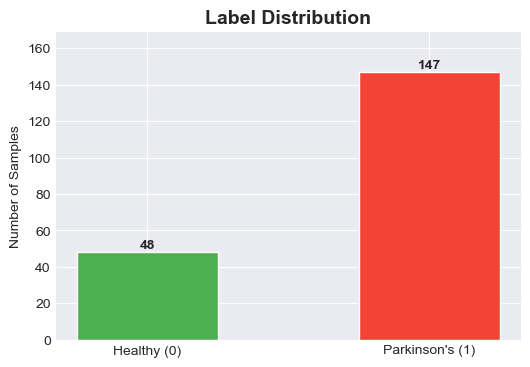

'outputs\\label_distribution.png'

In [10]:
visualization = VisualizationManager()
visualization.plot_label_distribution(data)

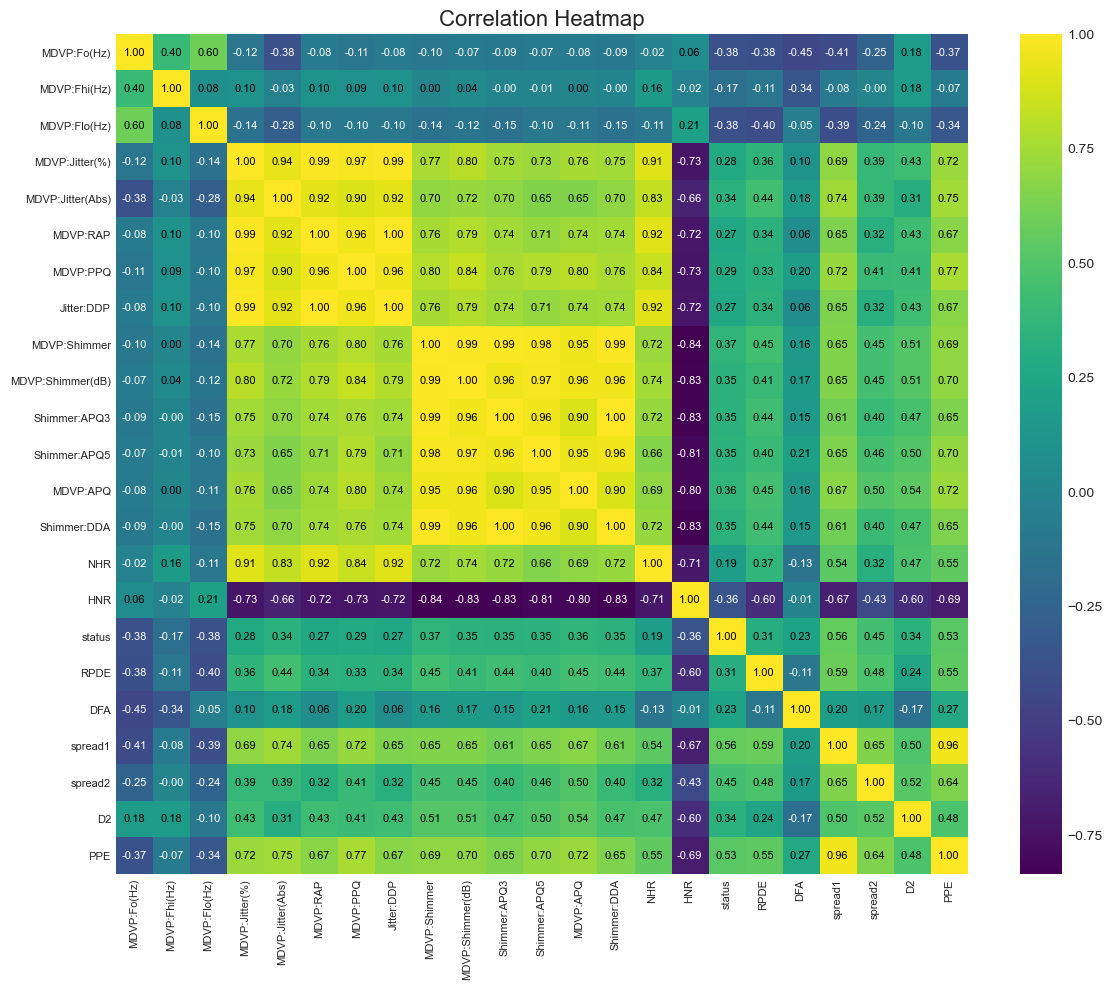

'outputs\\feature_correlation.png'

In [11]:
visualization.plot_feature_correlation(data)

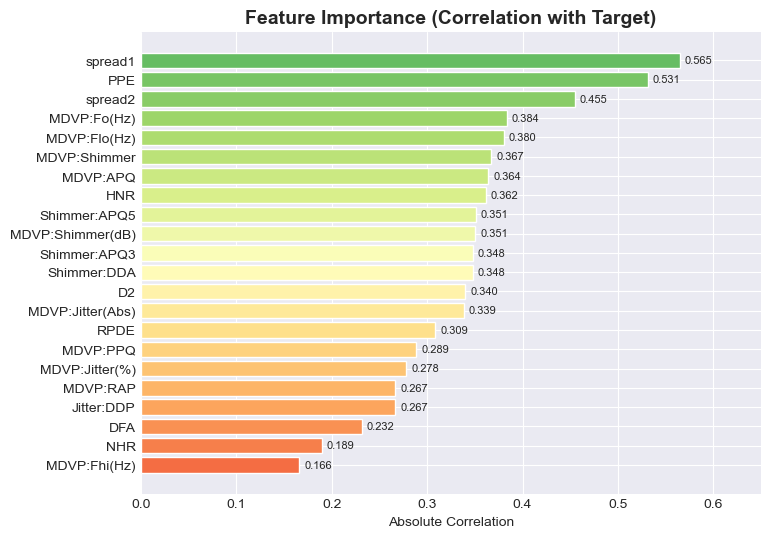

'outputs\\feature_importance.png'

In [12]:
visualization.plot_feature_importance(data)